# The Price of Waiting \U000023F3
### "Wait for confirmation" is advice with an invoice attached

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Investable](https://img.shields.io/badge/Tradability-Investable-2ea44f?style=flat-square)

Don't act on the first crossing. Wait for the signal to hold. Everybody says it, nobody prices
it — and it is genuinely two things at once: fewer false starts, and later entries. This
notebook measures both halves separately instead of netting them into one number.

> \U0001F4D3 **This is the plain-language layer.** The grid, the delay accounting and the
> choose-*k*-out-of-sample test are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Does waiting reduce whipsaw? | Yes, dramatically, and most on the signals that whipsaw most. |
| Does it improve returns? | Sometimes. Roughly a coin flip across tapes and signals. |
| What does it cost? | Thousands of sessions spent in cash while the signal was already right. |
| Could you pick the right waiting period? | Not reliably — the best *k* on the first half of a tape is rarely the best on the second. |

## 1 · The claim

> *"Never act on the first crossing. Wait for two or three closes to confirm — that's how you
> avoid getting chopped up."*

The first half of that is a real, measurable effect. The second half quietly assumes the
avoided trades were the bad ones.

In [2]:
from confirm_delay import data, strategy as st

px = data.load_prices()
cash = px[data.CASH].dropna()
print(f"as-of {data.AS_OF}")
for tk in data.RISKY:
    s = px[tk].dropna()
    print(f"  {tk:5s} {s.index[0].date()} -> {s.index[-1].date()}  n={len(s):,}")
raw = {s: st.raw_signal(px['SPY'].dropna(), s) for s in st.SIGNALS}
for s, v in raw.items():
    flips = int(v.dropna().astype(int).diff().abs().sum())
    print(f"  SPY {st.SIGNAL_LABEL[s]:34s} {flips:4d} crossings "
          f"({flips / (len(v.dropna()) / 252):.1f} a year)")

as-of 2026-06-30
  SPY   1993-01-29 -> 2026-06-30  n=8,411
  IWM   2000-05-26 -> 2026-06-30  n=6,561
  TLT   2002-07-30 -> 2026-06-30  n=6,018
  GLD   2004-11-18 -> 2026-06-30  n=5,436
  SPY Price above the 200-day average     214 crossings (6.6 a year)
  SPY 12-1 momentum positive              118 crossings (3.6 a year)
  SPY 14-day RSI above 50                 894 crossings (26.8 a year)


Three signals with very different tempos. The RSI crosses its midpoint dozens of times a year;
the 200-day average crosses a handful. Confirmation should matter enormously for one and barely
at all for the other.

## 2 · What confirmation does to a signal

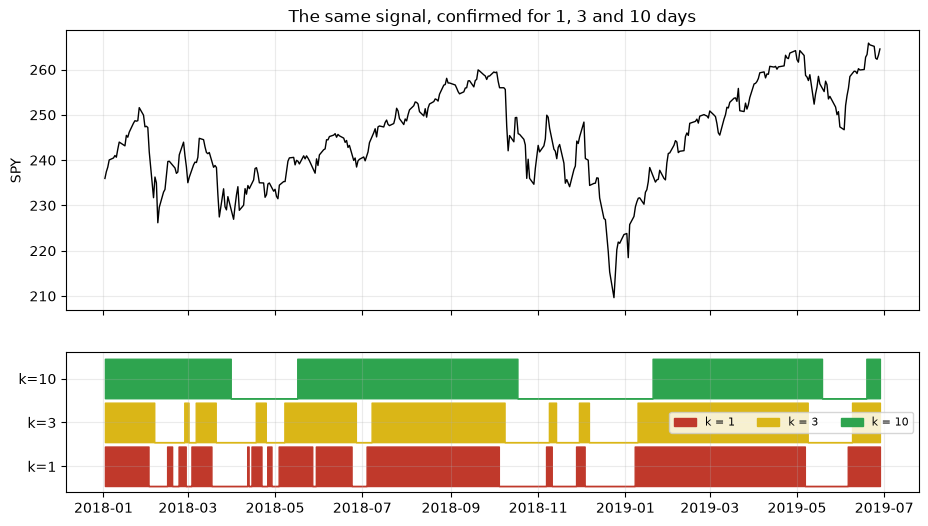

k= 1:  448 round trips, 81% closed within a month, median length 4 sessions


k= 3:  177 round trips, 51% closed within a month, median length 21 sessions
k=10:   60 round trips, 15% closed within a month, median length 62 sessions


In [3]:
spy = px["SPY"].dropna()
r = st.raw_signal(spy, "rsi14")
win = slice("2018-01-01", "2019-06-30")
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(spy.loc[win].index, spy.loc[win], color="k", lw=1)
axes[0].set_ylabel("SPY"); axes[0].set_title("The same signal, confirmed for 1, 3 and 10 days")
for k, colour, off in ((1, "#c0392b", 0), (3, "#dab617", 1), (10, "#2ea44f", 2)):
    c = st.confirm(r, k).loc[win].astype(int)
    axes[1].fill_between(c.index, off, off + c * 0.9, color=colour, step="mid",
                         label=f"k = {k}")
axes[1].set_yticks([0.45, 1.45, 2.45]); axes[1].set_yticklabels(["k=1", "k=3", "k=10"])
axes[1].legend(ncol=3, fontsize=8)
plt.show()
for k in (1, 3, 10):
    w = st.whipsaw_stats(st.confirm(r, k).shift(1).fillna(False))
    print(f"k={k:2d}: {w['n_trades']:4d} round trips, {w['whipsaw_share']:.0%} closed within a "
          f"month, median length {w['median_length']:.0f} sessions")

## 3 · Both halves of the trade-off

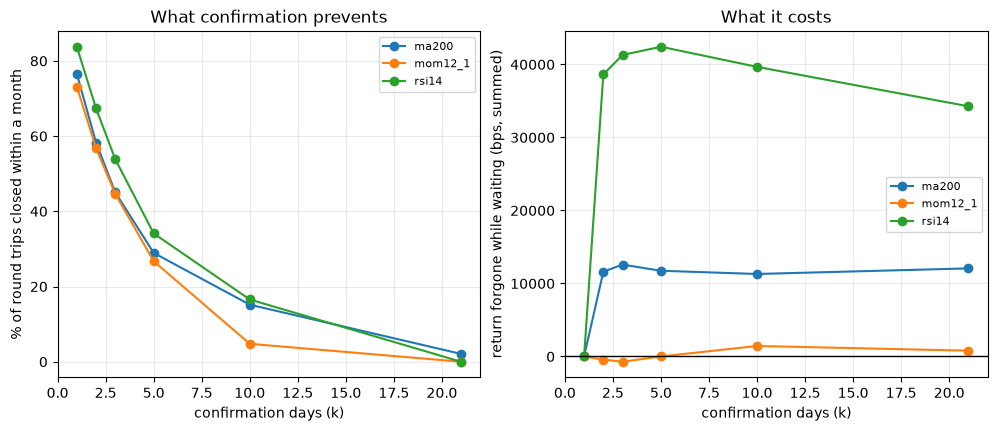

In [4]:
grid = st.full_grid(px, cash, data.RISKY, cost_bps=2.0)
ws = grid.pivot_table(index="k", columns="signal", values="ws_whipsaw_share")
delay = grid.pivot_table(index="k", columns="signal", values="delay_cost_bps")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
(ws * 100).plot(ax=axes[0], marker="o")
axes[0].set_ylabel("% of round trips closed within a month")
axes[0].set_title("What confirmation prevents"); axes[0].legend(fontsize=8, title="")
delay.plot(ax=axes[1], marker="o")
axes[1].axhline(0, color="k", lw=1)
axes[1].set_ylabel("return forgone while waiting (bps, summed)")
axes[1].set_title("What it costs"); axes[1].legend(fontsize=8, title="")
for a in axes:
    a.set_xlabel("confirmation days (k)")
plt.show()

> \U0001F52C **For the quants.** The left panel is monotone and reliable — that is a mechanical
> property of the operator. The right panel is where the money is, and it grows with *k* just
> as reliably. The question is only which grows faster in Sharpe terms.

## 4 · Did it pay?

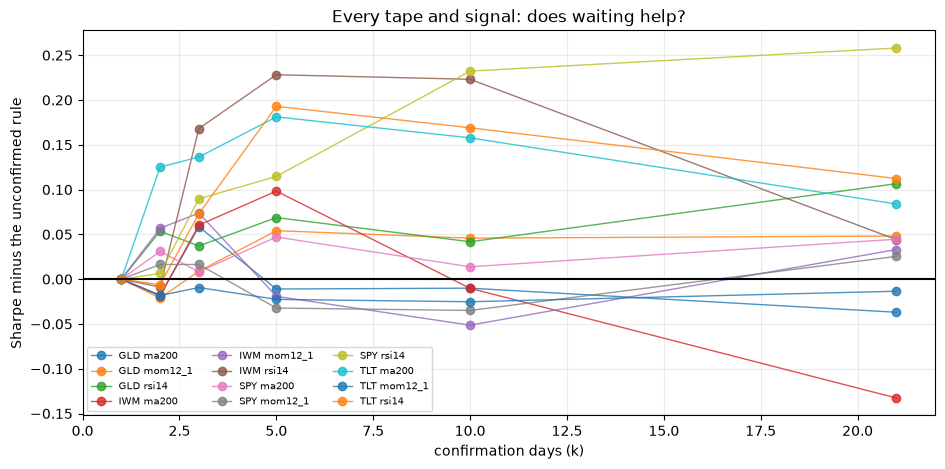

ticker  signal  best_k  sharpe_best  sharpe_k1   gain  whipsaw_k1  whipsaw_best
   GLD   ma200       3       0.6660     0.6080 0.0580      0.7750        0.4380
   GLD mom12_1       5       0.6420     0.5880 0.0540      0.7290        0.2220
   GLD   rsi14      21       0.6290     0.5230 0.1070      0.8350        0.0000
   IWM   ma200       5       0.5300     0.4310 0.0980      0.7180        0.1110
   IWM mom12_1       3       0.4710     0.3970 0.0740      0.7690        0.6100
   IWM   rsi14       5       0.4710     0.2420 0.2280      0.8410        0.3010
   SPY   ma200       5       0.7950     0.7480 0.0470      0.7130        0.2410
   SPY mom12_1      21       0.7970     0.7720 0.0250      0.7670        0.0000
   SPY   rsi14      21       0.7100     0.4520 0.2580      0.8080        0.0000
   TLT   ma200       5       0.2860     0.1050 0.1810      0.8560        0.4850
   TLT mom12_1       1       0.2890     0.2890 0.0000      0.6620        0.6620
   TLT   rsi14       5       0.4190     

In [5]:
sh = grid.pivot_table(index="k", columns=["ticker", "signal"], values="sharpe")
rel = sh - sh.loc[1]
fig, ax = plt.subplots(figsize=(11, 5))
for col in rel.columns:
    ax.plot(rel.index, rel[col], marker="o", lw=1, alpha=0.8,
            label=f"{col[0]} {col[1]}")
ax.axhline(0, color="k", lw=1.5)
ax.set_xlabel("confirmation days (k)"); ax.set_ylabel("Sharpe minus the unconfirmed rule")
ax.set_title("Every tape and signal: does waiting help?")
ax.legend(ncol=3, fontsize=7)
plt.show()
best = st.best_k(grid)
print(best.round(3).to_string(index=False))

## 5 · The verdict

**Signal: Real.** Yes, mechanically, and by a lot. Requiring five consecutive days of agreement cuts the share of round trips closed inside a month from **78%** to **30%** and the number of trades from 7.1 to 1.9 a year, across 12 tape × signal cells; the reduction holds on **100%** of them. The fast signal is where it bites: RSI's whipsaw share falls from 84% to 34%, while the 200-day average — which barely whipsaws to begin with — has little to gain.

**Tradability: Investable.** The waiting is not free. Across the grid the confirmed arms spent **3,636 sessions** holding cash while the raw signal was already positive, worth **-216,670 bps** of forgone return, against **+253,703 bps** avoided by exiting late. Some confirmation length beat the unconfirmed rule on Sharpe in **92%** of cells, by **+0.110** on average — and the winning length is different in almost every cell (4 different values of *k* across 12 cells), which is what choosing it in hindsight looks like.

## 6 · Going further \U0001F6AA

- **A price band** instead of a time delay — require the crossing to exceed the average by x%
  — is the other standard filter and trades off differently.
- **Confirmation on the exit only.** Most of the whipsaw damage is round trips; delaying only
  one leg is a cheaper version of the same idea.
- **Cost sensitivity.** At 2 bps a switch, trading is nearly free. At 25 bps the calculus
  changes and confirmation starts paying for itself.